# Capse.jl chains
In this notebook we will show how to use the `Capse.jl` emulator in combination with `Turing.jl`, performing a Planck lite analysis. In particolar, we are gonna show:

- How to compute the Maximum A Posteriori (MAP), using the L-BFGS method provided by Optim.jl
- How to use `Pathfinder.jl` to obtain a quick posterior estimate and initialize chains
- How to use NUTS and MicroCanonical Hamiltonian MonteCarlo as sampling algorithms

Let us start activating the `Julia` environment

In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Desktop/work/papers/capse_paper/standard_emulator`


If you still have to install all the relevant packages, just run the following commands (this need to be done only once!)

```julia
Pkg.instantiate()
Pkg.resolve()
```

We can now load the relevant packages

In [2]:
using Turing
using Capse
using NPZ
using PlanckLite
using BenchmarkTools
using Plots
using Optim
using ForwardDiff
using Zygote
using LinearAlgebra
using Pathfinder
using MicroCanonicalHMC
using Transducers
using StatsPlots
using PairPlots
using LaTeXStrings
using CairoMakie
using MCMCChains
include("utils.jl");

Here we initialize one of the trained emulators.

This is done using the method `load_emulator`, which takes as input:
- the path to the trained emulator folder
- a keywork argument, used to decide the emulator backend (here we use `Lux.jl`)

In [3]:
CℓTT_emu = Capse.load_emulator("../weights/weights_cosmopowerspace_10000/TT/"; emu = Capse.LuxEmulator);

After instantiating our emulator, we can retrieve some informations about it

In [4]:
Capse.get_emulator_description(CℓTT_emu)

The parameters the model has been trained are, in the following order: ln10As, ns, H0, ωb, ωc, τ.
The emulator has been trained by Marco Bonici.
Marco Bonici email is bonici.marco@gmail.com.
The emulator has been trained on the high-precision-settings prediction as computed by the CAMB Boltzmann solver.


Let us benchmark `Capse.jl` against some random input

In [5]:
x = rand(6)
y1 = Capse.get_Cℓ(x, CℓTT_emu) #let us save the output
@benchmark Capse.get_Cℓ($x, $CℓTT_emu)

BenchmarkTools.Trial: 10000 samples with 1 evaluation.
 Range (min … max):  40.347 μs …  4.044 ms  ┊ GC (min … max): 0.00% … 97.43%
 Time  (median):     43.303 μs              ┊ GC (median):    0.00%
 Time  (mean ± σ):   45.710 μs ± 59.493 μs  ┊ GC (mean ± σ):  4.01% ±  4.45%

         ▄██▆▄                                                 
  ▂▂▃▆▆▆▇██████▆▅▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▂▂ ▃
  40.3 μs         Histogram: frequency by time        58.1 μs <

 Memory estimate: 161.34 KiB, allocs estimate: 59.

We can also use `SimpleChains.jl` as a backend

In [6]:
CℓTT_emu = Capse.load_emulator("../weights/weights_cosmopowerspace_10000/TT/", emu = Capse.SimpleChainsEmulator);
y2 = Capse.get_Cℓ(x, CℓTT_emu)
@benchmark Capse.get_Cℓ($x, $CℓTT_emu)

BenchmarkTools.Trial: 10000 samples with 1 evaluation.
 Range (min … max):  44.535 μs … 635.640 μs  ┊ GC (min … max): 0.00% … 90.01%
 Time  (median):     48.461 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   49.642 μs ±  16.065 μs  ┊ GC (mean ± σ):  1.14% ±  3.21%

               ▃▇█▄▁                                            
  ▂▂▂▂▂▂▂▃▃▄▅▆██████▇▇▆▅▅▅▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂ ▃
  44.5 μs         Histogram: frequency by time         59.1 μs <

 Memory estimate: 117.47 KiB, allocs estimate: 8.

We can check that the two backends output matches

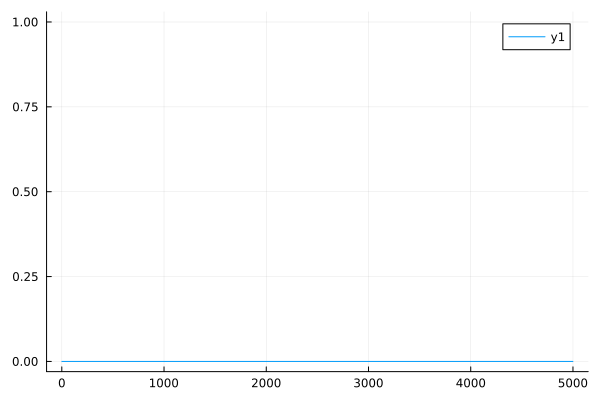

In [7]:
Plots.plot(y1 .- y2)

We are now ready to instantiate all of our emulators (we are using the `Lux.jl` backend)

In [8]:
CℓEE_emu = Capse.load_emulator("../weights/weights_cosmopowerspace_10000/EE/", emu = Capse.LuxEmulator);

In [9]:
CℓTE_emu = Capse.load_emulator("../weights/weights_cosmopowerspace_10000/TE/", emu = Capse.LuxEmulator);

In [10]:
CℓPP_emu = Capse.load_emulator("../weights/weights_cosmopowerspace_10000/PP/", emu = Capse.LuxEmulator);

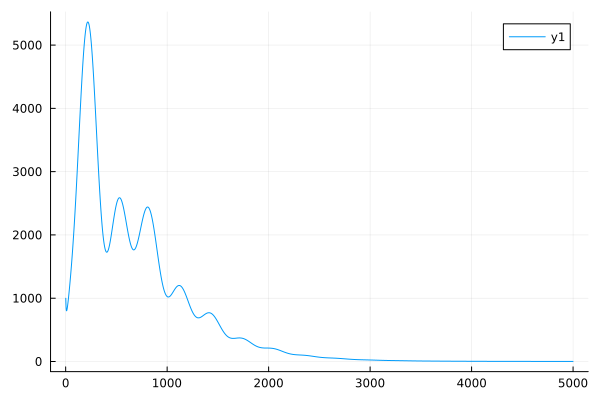

In [11]:
Plots.plot(Capse.get_Cℓ([3, 0.96, 67, 0.02, 0.12, 0.05], CℓTT_emu))

## PlanckLite & Turing

Here we are going to create some functions to analyze Planck data.
The first function, given a list of arguments, retrieves the binned $C_\ell$'s 

In [12]:
lsTT = 2:2508
lsTE = 2:1996
facTT=lsTT.*(lsTT.+1)./(2*π)
facTE=lsTE.*(lsTE.+1)./(2*π)

function call_emu_planck(θ, Emu_TT, Emu_TE, Emu_EE, facTT, facTE)
    return PlanckLite.bin_Cℓ(Capse.get_Cℓ(θ, Emu_TT)[1:2507]./facTT,
                            Capse.get_Cℓ(θ, Emu_TE)[1:1995]./facTE,
                            Capse.get_Cℓ(θ, Emu_EE)[1:1995]./facTE)
end

call_emu_planck (generic function with 1 method)

This other function is a closure, defining a more manageable version of the same function (in this way we don't have to pass some fixed arguments)

In [13]:
theory_planck(θ) = call_emu_planck(θ, CℓTT_emu, CℓTE_emu, CℓEE_emu, facTT, facTE)

theory_planck (generic function with 1 method)

In [14]:
@benchmark theory_planck($x)

BenchmarkTools.Trial: 10000 samples with 1 evaluation.
 Range (min … max):  144.108 μs … 959.248 μs  ┊ GC (min … max): 0.00% … 68.04%
 Time  (median):     148.621 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   154.342 μs ±  59.433 μs  ┊ GC (mean ± σ):  2.59% ±  5.61%

     ▄▇█▇█▇▄▂▁                                                   
  ▂▄▇█████████▇▆▆▅▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▃
  144 μs           Histogram: frequency by time          178 μs <

 Memory estimate: 552.83 KiB, allocs estimate: 141.

Let us now define a dummy scalar function (i.e. a function $\mathrm{R}^n\rightarrow\mathrm{R}^1$ ), that we are gonna use as a benchmark to evaluate gradients

In [15]:
mytest(x) = sum(abs2, theory_planck(x))

mytest (generic function with 1 method)

In [16]:
@benchmark mytest($x)

BenchmarkTools.Trial: 10000 samples with 1 evaluation.
 Range (min … max):  144.007 μs …  1.141 ms  ┊ GC (min … max): 0.00% … 70.74%
 Time  (median):     150.107 μs              ┊ GC (median):    0.00%
 Time  (mean ± σ):   156.141 μs ± 59.999 μs  ┊ GC (mean ± σ):  2.56% ±  5.57%

     ▁▅▆▇██▆▅▃▂▂                                                
  ▁▂▅████████████▇▆▆▅▄▄▃▃▂▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▃
  144 μs          Histogram: frequency by time          181 μs <

 Memory estimate: 552.84 KiB, allocs estimate: 142.

We are now ready to perform autodiff! Here we are gonna use two different AD backends:

- `ForwardDiff.jl`, that performs Forward AD, which scales as the number of input parameters (with some caveats)
- `Zygote.jl`, that performs Backward AD, which scales as the number of output parameters

In [17]:
@benchmark ForwardDiff.gradient(mytest, $x)

BenchmarkTools.Trial: 3042 samples with 1 evaluation.
 Range (min … max):  1.474 ms …   3.820 ms  ┊ GC (min … max): 0.00% … 19.97%
 Time  (median):     1.607 ms               ┊ GC (median):    0.00%
 Time  (mean ± σ):   1.642 ms ± 151.502 μs  ┊ GC (mean ± σ):  1.39% ±  4.68%

     ▁▄▆███▇▇▆▇▇▅▃▁                                           ▂
  ▇▆████████████████▆▆▅▁▅▅▁▁▄▁▄▄▁▁▁▄▁▁▁▁▁▁▁▁▁▁▁▄▁▅▁▅▇█▇███▇██ █
  1.47 ms      Histogram: log(frequency) by time      2.33 ms <

 Memory estimate: 4.00 MiB, allocs estimate: 190.

In [18]:
@benchmark Zygote.gradient(mytest, $x)

BenchmarkTools.Trial: 2721 samples with 1 evaluation.
 Range (min … max):  1.585 ms …   4.786 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     1.727 ms               ┊ GC (median):    0.00%
 Time  (mean ± σ):   1.831 ms ± 306.367 μs  ┊ GC (mean ± σ):  5.64% ± 9.77%

   ▃█▆▄▄▃▅▆█▄                                                  
  ▄███████████▅▄▃▃▃▂▂▂▂▂▂▂▂▁▂▁▂▁▂▁▂▁▁▁▁▁▁▂▃▃▃▃▃▃▃▃▄▃▃▄▃▄▃▃▃▂▂ ▃
  1.59 ms         Histogram: frequency by time        2.65 ms <

 Memory estimate: 16.99 MiB, allocs estimate: 786.

In this specific example, the difference is not that big, since we are differentiating wrt only 6 parameters (but things get quickly better for `Zygote.jl` as the dimensionality of the problem increses).

We are now ready to instantiate our problem using `Turing.jl!`

# Creating a likelihood with a Probabilistic Programming Language

In this part of the notebook we are gonna show how to use `Turing.jl`, the state-of-the-art Probabilistic Programming Language (PPL) in the `Julia` ecosystem.

Before starting, we can take advantage of a bit of math to improve the performance of our inference.

Since the Covariance matrix we are gonna use does not depend on the model parameters, we can reparametrize our problem; let us define the following quantities

$\Gamma = \mathrm{sqrt}(\Lambda)$

$i\Gamma=\mathrm{inv}(\Gamma)$

$D = i\Gamma \cdot d$

We can now sample a MvNormal with an easier covariance matrix

$D \sim \mathrm{MvNormal}(i\Gamma\cdot t(\theta), I)$

The advantage of this reparametrization is that we compute the inverse of a matrix just once and not at every step of the MCMC, without resoirting to any approximation: the two likelihood defined are mathematically equivalent.

The covariance matrix and the data are supplied by the `PlanckLite.jl` package.

In [19]:
Γ = sqrt(PlanckLite.cov)
iΓ = inv(Γ)
D = iΓ * PlanckLite.data;

Although this is a bit different from the way we are used to code likelihoods in cosmology, it is easy to explain how to use a PPL such as `Turing.jl`.

When we use the "$\sim$" symbol, we are saying that the left-hand-side is sampled from the distribution on the right-hand-side

In [20]:
@model function CMB_planck(D, iΓ)
    #prior on model parameters
    ln10As ~ Uniform(0.25, 0.35)
    ns     ~ Uniform(0.88, 1.06)
    h      ~ Uniform(0.60, 0.80)
    ωb     ~ Uniform(0.1985, 0.25)
    ωc     ~ Uniform(0.08, 0.20)
    τ      ~ Normal(0.0506, 0.0086)
    yₚ     ~ Normal(1.0, 0.0025)

    θ = [10*ln10As, ns, 100*h, ωb/10, ωc, τ]

    #compute theoretical prediction
    pred = iΓ * theory_planck(θ) ./(yₚ^2)
    #compute likelihood
    D ~ MvNormal(pred, I)

    return nothing
end

CMB_model_planck = CMB_planck(D, iΓ);

Since `D` is supplied to our `model` as an input, `Turing.jl` understand it to be a part of the likelihood, rather than a parameter drawn from the prior.

Let us perform the MAP computation. `Turing.jl` has been interfaced with `Optim.jl`, which provides some powerful minimization methods such as L-BFGS.

In [21]:
bestfit_Planck = optimize(CMB_model_planck, MAP(), Optim.Options(iterations=100000, allow_f_increases=true))
@benchmark optimize(CMB_model_planck, MAP(), Optim.Options(iterations=100000, allow_f_increases=true))

BenchmarkTools.Trial: 10 samples with 1 evaluation.
 Range (min … max):  321.498 ms … 878.614 ms  ┊ GC (min … max): 1.63% … 1.42%
 Time  (median):     457.035 ms               ┊ GC (median):    1.39%
 Time  (mean ± σ):   519.653 ms ± 171.148 ms  ┊ GC (mean ± σ):  1.48% ± 0.23%

  █       ███  █  █   █                █ █                    █  
  █▁▁▁▁▁▁▁███▁▁█▁▁█▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█ ▁
  321 ms           Histogram: frequency by time          879 ms <

 Memory estimate: 556.26 MiB, allocs estimate: 44285.

The minimization takes less than half a second!

We are going to run a chain, with 250 adaptation steps and 500 steps (note that `Turing.jl` will not retrieve the burn-in steps)

In [22]:
nsteps = 500
nadapts = 250;

Before starting chains, let us use `Pathfinder.jl`, a `Julia` implementation of the Pathfinder algorithm. Pathfinder is an approximate method that quickly gives approximate samples from the posterior distribution. It can be used to replace a standard MCMC or initialize it. Here we are gonna use the parallel version, that performs multiples runs and merges them.

In [23]:
result_multi = multipathfinder(CMB_model_planck, 2000; nruns=4)

Multi-path Pathfinder result
  runs: 4
  draws: 2000
  Pareto shape diagnostic: 0.44 (good)

In [24]:
result_multi.draws_transformed

Chains MCMC chain (2000×7×1 Array{Float64, 3}):

Iterations        = 1:1:2000
Number of chains  = 1
Samples per chain = 2000
parameters        = ln10As, ns, h, ωb, ωc, τ, yₚ

Summary Statistics
  parameters      mean       std      mcse    ess_bulk    ess_tail      rhat   ⋯
      Symbol   Float64   Float64   Float64     Float64     Float64   Float64   ⋯

      ln10As    0.3049    0.0018    0.0000   2016.9907   1880.6851    0.9998   ⋯
          ns    0.9630    0.0042    0.0001   1997.4309   1600.6857    1.0000   ⋯
           h    0.6706    0.0058    0.0001   1871.7659   1579.2585    1.0003   ⋯
          ωb    0.2234    0.0014    0.0000   2077.3554   2116.6681    1.0001   ⋯
          ωc    0.1207    0.0013    0.0000   1864.4694   2044.2116    1.0005   ⋯
           τ    0.0560    0.0084    0.0002   2082.6029   2004.6583    1.0000   ⋯
          yₚ    1.0004    0.0025    0.0001   1945.4915   2026.6529    0.9999   ⋯
                                                                1 column omi

In [25]:
@time multipathfinder(CMB_model_planck, 2000; nruns=4)

┌ Warning: 1 (1.6%) updates to the inverse Hessian estimate were rejected to keep it positive definite.
└ @ Pathfinder ~/.julia/packages/Pathfinder/OduAC/src/singlepath.jl:213


  5.500411 seconds (2.63 M allocations: 5.089 GiB, 2.87% gc time, 8.15% compilation time)


Multi-path Pathfinder result
  runs: 4
  draws: 2000
  Pareto shape diagnostic: 0.62 (ok)

Pathfinder is incredibly fast: it performed the analysis on my laptop in as few as 5 seconds. However, it is an approximate method. Although it might not always used to give a faithful approximation of the posterior, it is very useful in starting the chains close to the typical set.

Here we are gonna use some Pathfinder draws to initialize our chains (here the snippet of code is written as if we had to run 4 chains, so we took 4 samples from Pathfinder's draws).

In [26]:
init_params = collect.(eachrow(result_multi.draws_transformed.value[1:4, :, 1]));

We are now ready to start the No-U-Turn-Sampler (NUTS) chains!
We need to set:
- the number of burn-in and accepted steps
- the target acceptance-ratio (here we ar gonna use the standard 0.75)
- the initial point for our chains
- the AD backend (we are using both `ForwardDiff.jl` and `Zygote.jl`)

In [27]:
chains_planck_nuts_fd = sample(CMB_model_planck, NUTS(nadapts, 0.75, adtype=AutoForwardDiff()), nsteps; init_params = init_params[1])

┌ Info: Found initial step size
└   ϵ = 0.00078125
Sampling: 100%|█████████████████████████████████████████| Time: 0:03:08


Chains MCMC chain (500×19×1 Array{Float64, 3}):

Iterations        = 251:1:750
Number of chains  = 1
Samples per chain = 500
Wall duration     = 194.1 seconds
Compute duration  = 194.1 seconds
parameters        = ln10As, ns, h, ωb, ωc, τ, yₚ
internals         = lp, n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size

Summary Statistics
  parameters      mean       std      mcse   ess_bulk   ess_tail      rhat   e ⋯
      Symbol   Float64   Float64   Float64    Float64    Float64   Float64     ⋯

      ln10As    0.3050    0.0018    0.0001   219.0364   218.8388    0.9981     ⋯
          ns    0.9622    0.0042    0.0003   236.8397   224.9930    0.9995     ⋯
           h    0.6697    0.0058    0.0004   220.2192   246.2142    1.0151     ⋯
          ωb    0.2233    0.0015    0.0001   238.6689   283.3097    1.0029     ⋯
          ωc    0.1209    0.0013    0.0001   21

In [28]:
chains_planck_nuts_zy = sample(CMB_model_planck, NUTS(nadapts, 0.75, adtype=AutoZygote()), nsteps; init_params = init_params[1])

┌ Info: Found initial step size
└   ϵ = 0.00078125
Sampling: 100%|█████████████████████████████████████████| Time: 0:04:55


Chains MCMC chain (500×19×1 Array{Float64, 3}):

Iterations        = 251:1:750
Number of chains  = 1
Samples per chain = 500
Wall duration     = 350.16 seconds
Compute duration  = 350.16 seconds
parameters        = ln10As, ns, h, ωb, ωc, τ, yₚ
internals         = lp, n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size

Summary Statistics
  parameters      mean       std      mcse   ess_bulk   ess_tail      rhat   e ⋯
      Symbol   Float64   Float64   Float64    Float64    Float64   Float64     ⋯

      ln10As    0.3051    0.0017    0.0001   220.2501   262.0464    0.9999     ⋯
          ns    0.9633    0.0043    0.0004   134.4033   207.7059    1.0097     ⋯
           h    0.6708    0.0055    0.0006    82.5514   173.4699    1.0162     ⋯
          ωb    0.2234    0.0014    0.0001   122.1963   219.7040    1.0182     ⋯
          ωc    0.1206    0.0013    0.0001   

Let us plot our chains. As we can see, the samples looks almost uncorrelated, which is consistent with our estimate of the correlation length, which is between 2-3 for cosmological parameters.

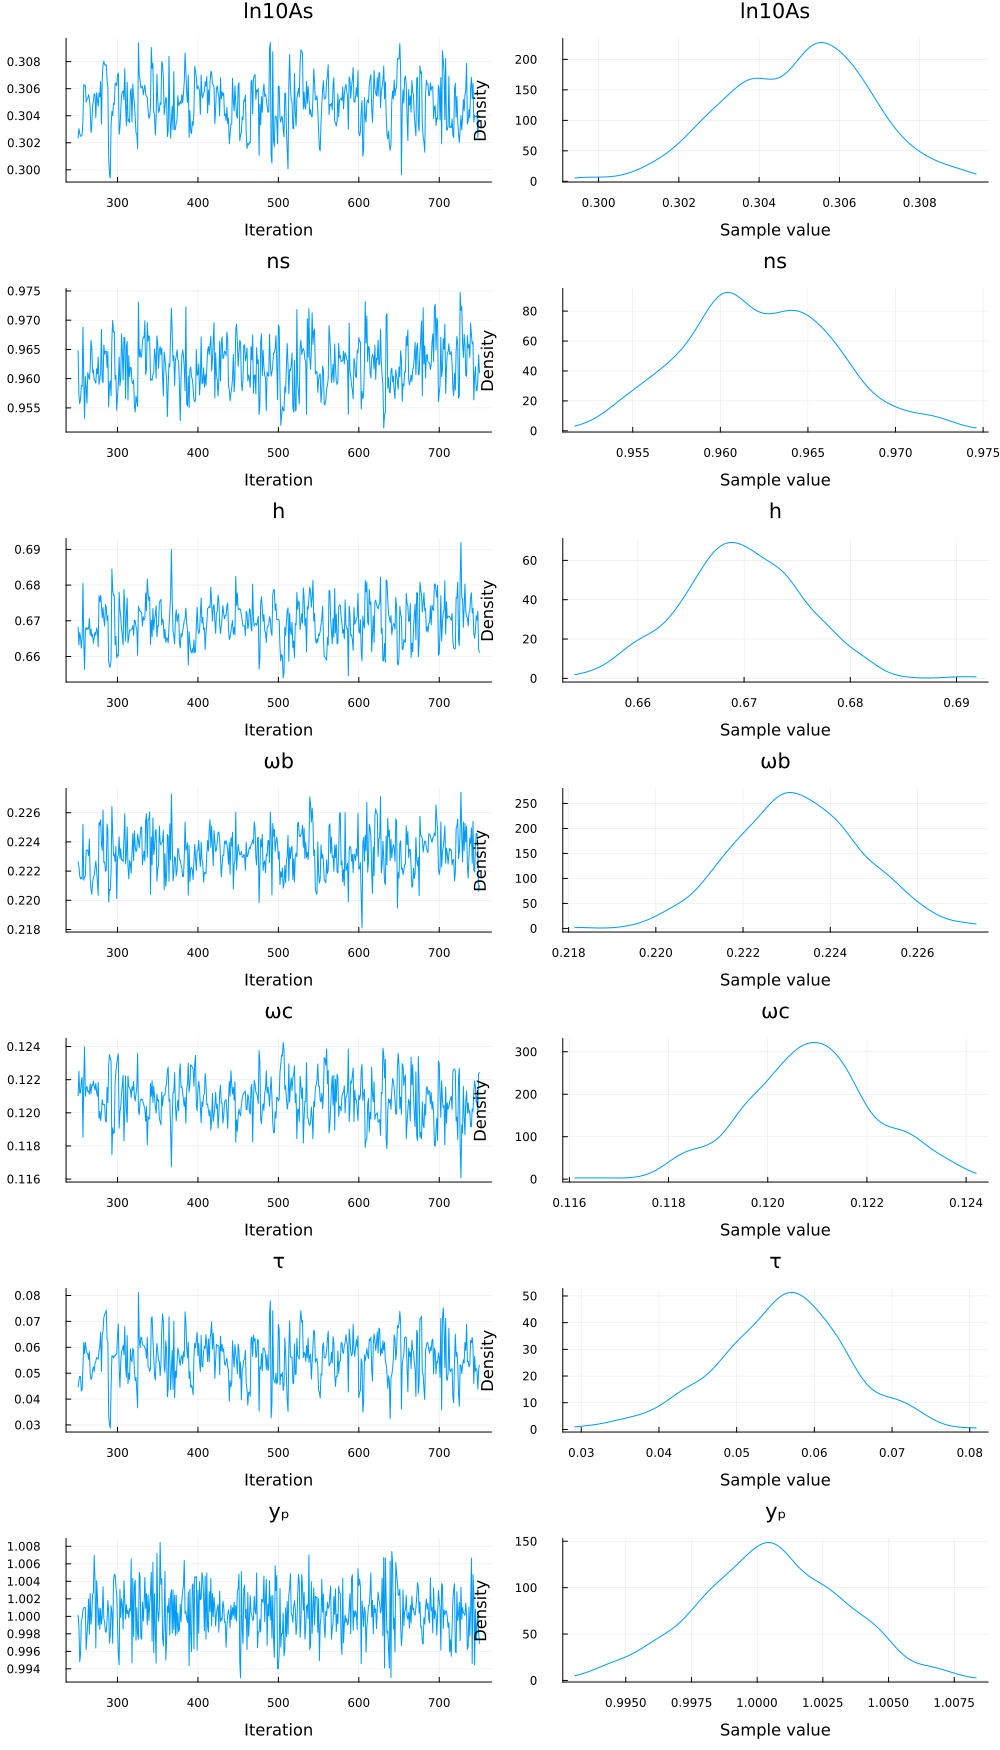

In [29]:
p = StatsPlots.plot(chains_planck_nuts_fd)
p

An interesting quantity we will compare with the MCHMC runs is the ESS per second

In [30]:
@info compute_ESS_s(chains_planck_nuts_fd)
@info compute_ESS_s(chains_planck_nuts_zy)

[ Info: 1.4316115055475638
[ Info: 0.5982431240576289


An ESS/s of 1.6 means that we can reach the (heuristic) threshold of 400 ESS in around 4 minutes and, taking advantage of the multiple processor, our analysis can be performed in around 1 minute.

## The MicroCanonical Hamiltonian MonteCarlo sampler
Here we will use the Julia implementation of the MCHMC sampler.
We will use 5'000 adaptation steps (that will be discarded) and 20'000 steps.

In [31]:
d = 7
nadapts = 5_000
nsteps = 20_000
spl = MCHMC(nadapts, 0.001; init_eps=0.05, L=sqrt(d), sigma=ones(d),
            adaptive=true, tune_L = false)

chains_planck_mchmc_fd = sample(CMB_model_planck, externalsampler(spl, adtype=AutoForwardDiff()),  nsteps; init_params = init_params[1])

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/kVZZH/src/ProgressMeter.jl:594
Tuning: 100%|███████████████████████████████████████████| Time: 0:00:13
  ϵ:     0.05102066214854412
  L:     2.6457513110645907
  dE/d:  0.004729967544871475
Sampling: 100%|█████████████████████████████████████████| Time: 0:01:16


Chains MCMC chain (20000×8×1 Array{Float64, 3}):

Iterations        = 1:1:20000
Number of chains  = 1
Samples per chain = 20000
Wall duration     = 91.26 seconds
Compute duration  = 91.26 seconds
parameters        = ln10As, ns, h, ωb, ωc, τ, yₚ
internals         = lp

Summary Statistics
  parameters      mean       std      mcse    ess_bulk    ess_tail      rhat   ⋯
      Symbol   Float64   Float64   Float64     Float64     Float64   Float64   ⋯

      ln10As    0.3049    0.0019    0.0002    100.9666    143.9236    1.0002   ⋯
          ns    0.9633    0.0043    0.0002    329.1387    602.8626    1.0009   ⋯
           h    0.6712    0.0061    0.0004    191.7749    304.5207    1.0000   ⋯
          ωb    0.2236    0.0015    0.0001    186.6714    380.1942    1.0008   ⋯
          ωc    0.1206    0.0014    0.0001    231.9764    368.5426    1.0001   ⋯
           τ    0.0559    0.0092    0.0009    107.2174    165.5890    1.0001   ⋯
          yₚ    1.0005    0.0023    0.0001   1182.5894   1866.9

In [32]:
chains_planck_mchmc_zy = sample(CMB_model_planck, externalsampler(spl, adtype=AutoZygote()),  nsteps; init_params = init_params[1])

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/kVZZH/src/ProgressMeter.jl:594
Tuning: 100%|███████████████████████████████████████████| Time: 0:00:27
  ϵ:     0.08112087915384472
  L:     2.6457513110645907
  dE/d:  -0.00038757694325600563
Sampling: 100%|█████████████████████████████████████████| Time: 0:02:20


Chains MCMC chain (20000×8×1 Array{Float64, 3}):

Iterations        = 1:1:20000
Number of chains  = 1
Samples per chain = 20000
Wall duration     = 185.34 seconds
Compute duration  = 185.34 seconds
parameters        = ln10As, ns, h, ωb, ωc, τ, yₚ
internals         = lp

Summary Statistics
  parameters      mean       std      mcse   ess_bulk   ess_tail      rhat   e ⋯
      Symbol   Float64   Float64   Float64    Float64    Float64   Float64     ⋯

      ln10As    0.3050    0.0016    0.0001   199.1125   347.8499    1.0024     ⋯
          ns    0.9629    0.0044    0.0002   430.3819   809.8944    1.0050     ⋯
           h    0.6703    0.0062    0.0004   261.0723   399.2903    1.0057     ⋯
          ωb    0.2233    0.0015    0.0001   280.8594   481.1121    1.0024     ⋯
          ωc    0.1207    0.0014    0.0001   303.1953   500.5493    1.0055     ⋯
           τ    0.0562    0.0076    0.0005   218.6089   364.1646    1.0012     ⋯
          yₚ    1.0004    0.0026    0.0002   284.5265   417.4

We are now ready to plot the different chains we obtained!

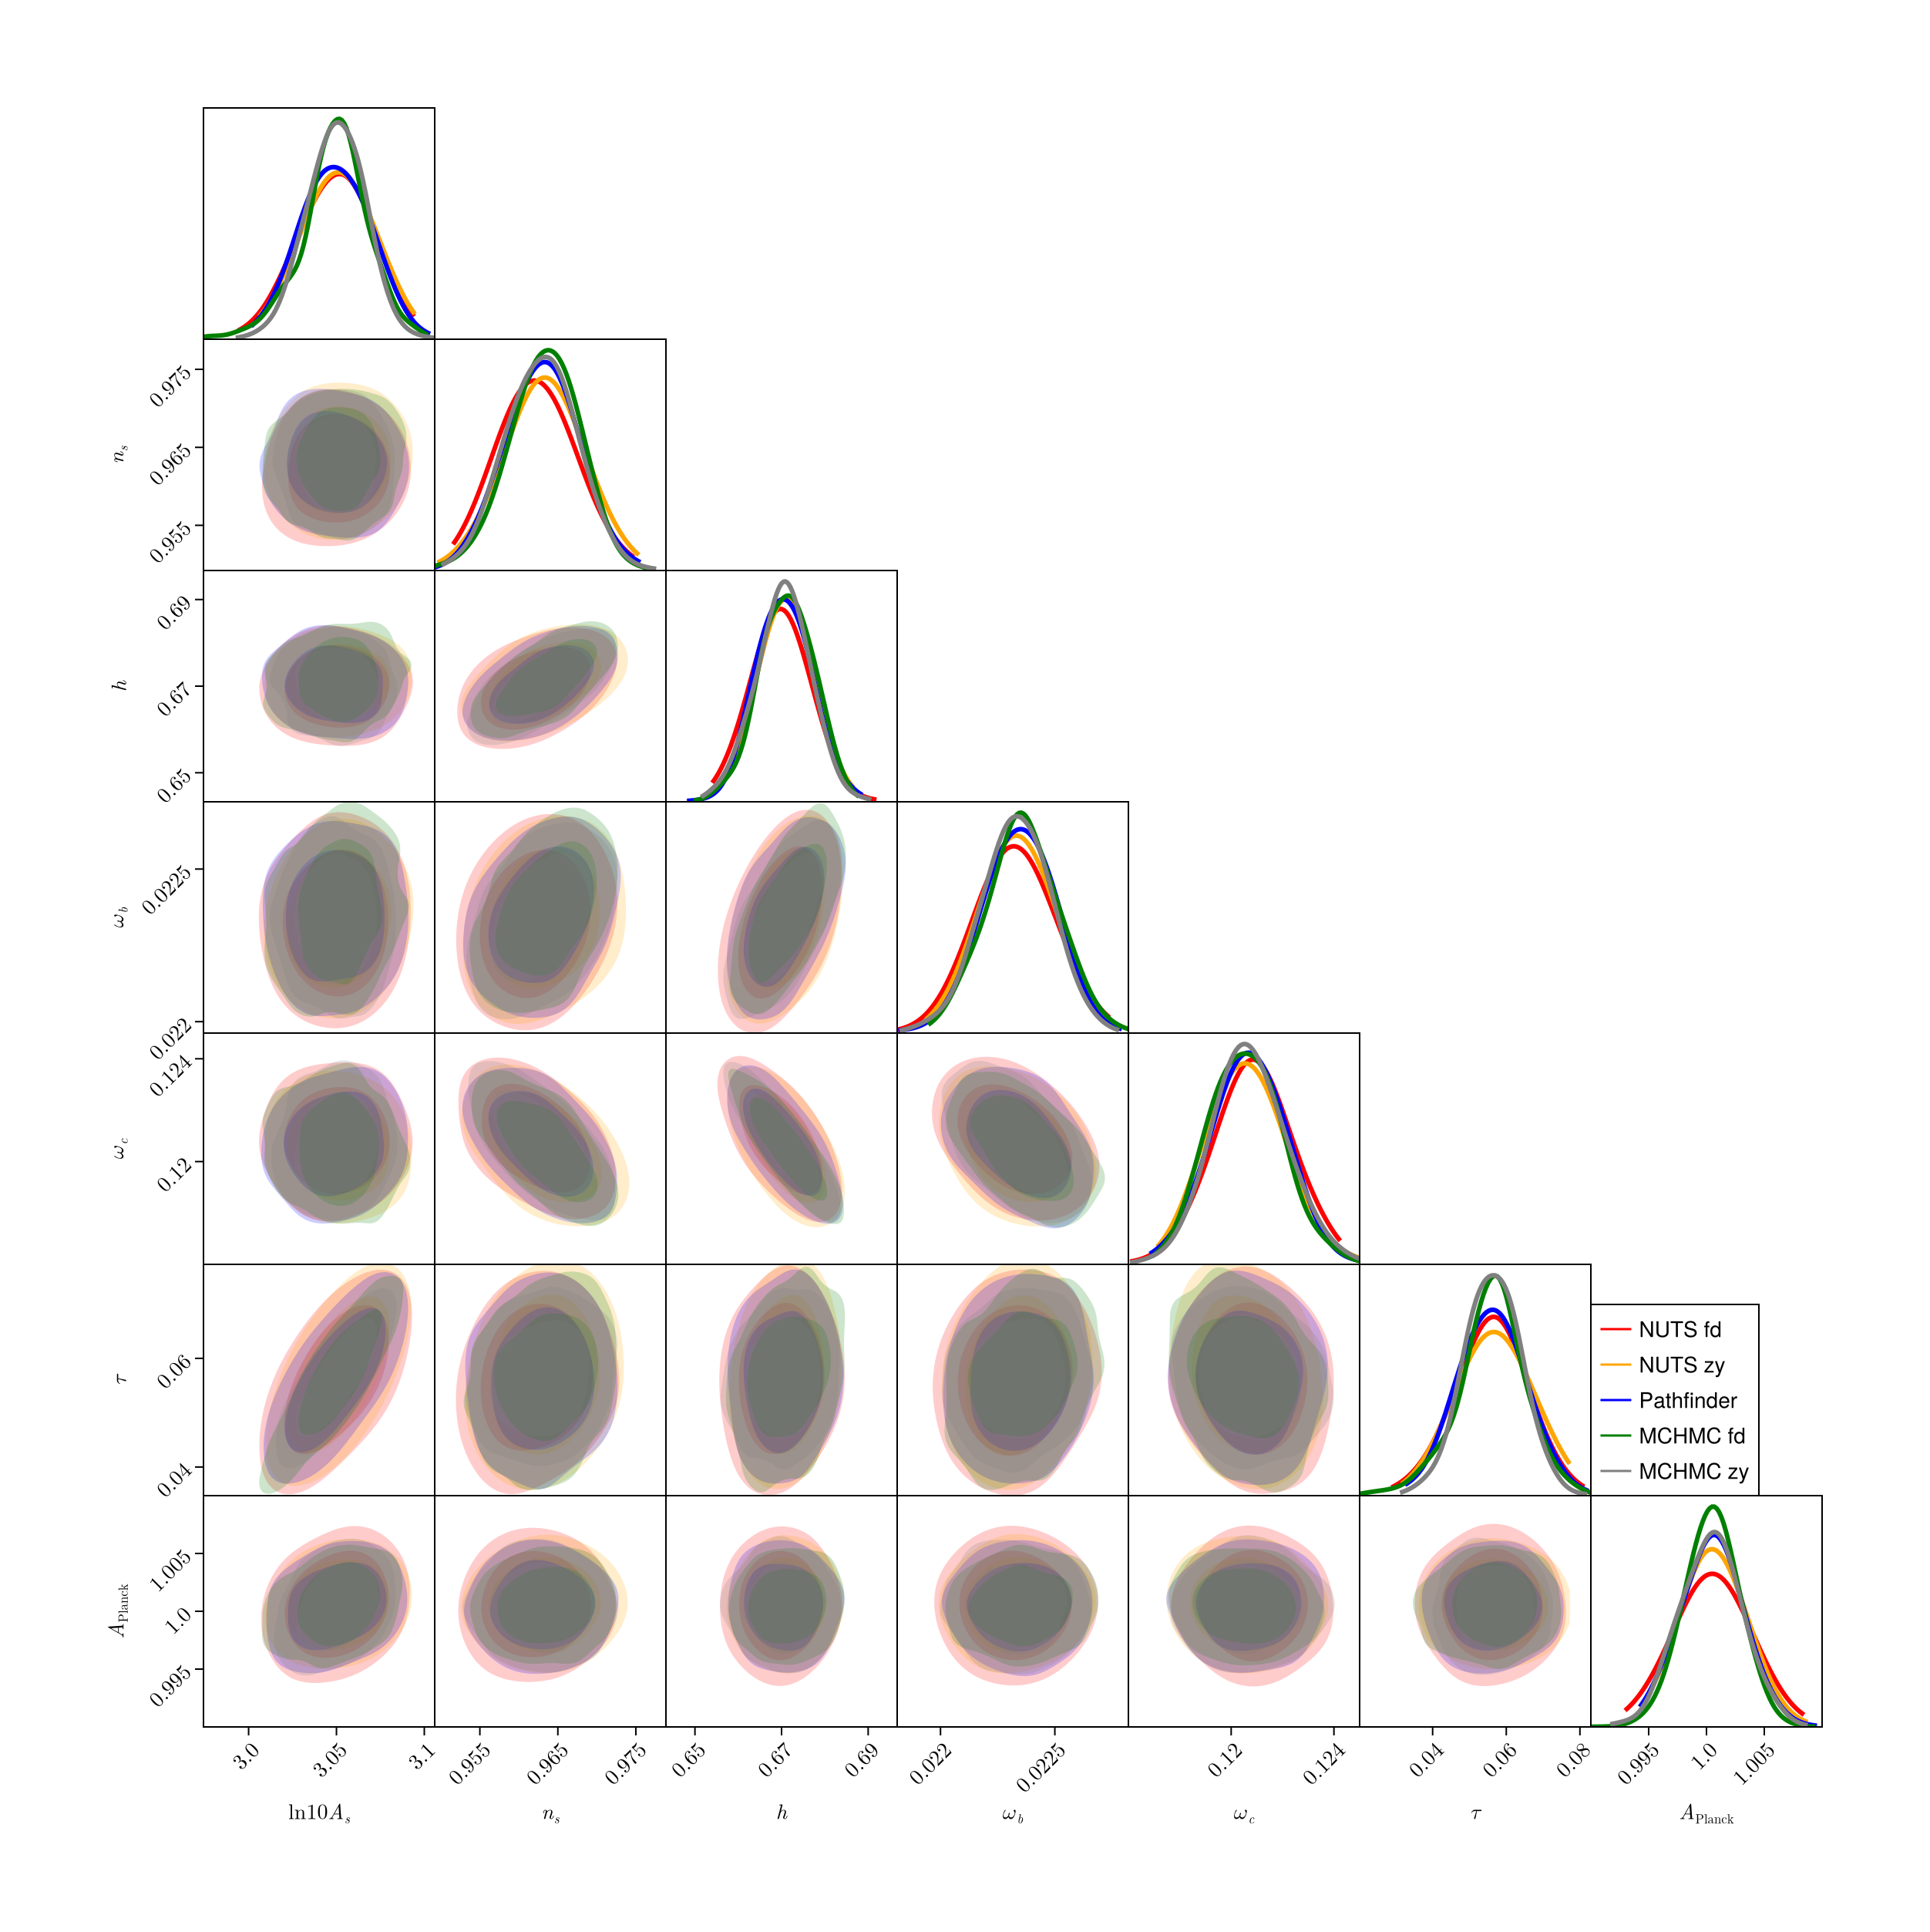

In [41]:
fig = pairplot(
    PairPlots.Series(
        chains_planck_nuts_fd,
        label="NUTS fd",
        color=:red,
    ) => (
        PairPlots.Contourf(
            sigmas=[1,2],
            color=(:red, 0.2),
            bandwidth=3,
            # bandwidth is the smoothing
        ),
        PairPlots.MarginDensity(
            linewidth=3,
            bandwidth=3,
        ),
    ),

    PairPlots.Series(
        chains_planck_nuts_zy,
        label="NUTS zy",
        color=:orange,
    ) => (
        PairPlots.Contourf(
            sigmas=[1,2],
            color=(:orange, 0.2),
            bandwidth=3,
            # bandwidth is the smoothing
        ),
        PairPlots.MarginDensity(
            linewidth=3,
            bandwidth=3,
        ),
    ),

    PairPlots.Series(
        result_multi.draws_transformed,
        label="Pathfinder",
        color=:blue,
    ) => (
        PairPlots.Contourf(
            sigmas=[1,2],
            color=(:blue, 0.2),
            bandwidth=3,
            # bandwidth is the smoothing
        ),
        PairPlots.MarginDensity(
            linewidth=3,
            bandwidth=3,
        ),
    ),
    PairPlots.Series(
        chains_planck_mchmc_fd,
        label="MCHMC fd",
        color=:green,
    ) => (
        PairPlots.Contourf(
            sigmas=[1,2],
            color=(:green, 0.2),
            bandwidth=3,
            # bandwidth is the smoothing
        ),
        PairPlots.MarginDensity(
            linewidth=3,
            bandwidth=3,
        ),
    ),
    PairPlots.Series(
        chains_planck_mchmc_zy,
        label="MCHMC zy",
        color=:grey,
    ) => (
        PairPlots.Contourf(
            sigmas=[1,2],
            color=(:grey, 0.2),
            bandwidth=3,
            # bandwidth is the smoothing
        ),
        PairPlots.MarginDensity(
            linewidth=3,
            bandwidth=3,
        ),
    ),
    #fullgrid=true,
    # Add LaTeX overrides for labels here!
    labels=Dict(
        :ln10As => L"\ln 10 A_s", # LaTeX
        :ns => L"n_s", # LaTeX
        :h => L"h", # LaTeX
        :ωb => L"\omega_b", # LaTeX
        :ωc => L"\omega_c", # LaTeX
        :τ => L"\tau", # LaTeX
        :yₚ => L"A_\mathrm{Planck}", # LaTeX
        :b => Makie.rich("long label α", color=:green)
    ),
    axis=(;
        h = (;
            ticks=(
                [0.65, 0.67, 0.69],
                [L"0.65", L"0.67", L"0.69"]
            ), lims=(;low=0.65-0.67*0.01, high=0.69+0.67*0.01)

        ),
        ns = (;
            ticks=(
                [0.955, 0.965, 0.975],
                [L"0.955", L"0.965", L"0.975"]
            ), lims=(;low=0.955-0.965*0.006, high=0.975+0.965*0.004)
        ),
        ln10As = (;
            ticks=(
                [0.3, 0.305, 0.31],
                [L"3.0", L"3.05", L"3.1"]
            )#, lims=(;low=0.955-0.965*0.01, high=0.975+0.965*0.01)
        ),
        ωb = (;
            ticks=(
                [0.22, 0.225],
                [L"0.022", L"0.0225"]
            )#, lims=(;low=0.955-0.965*0.01, high=0.975+0.965*0.01)
        ),
        ωc = (;
            ticks=(
                [0.12, 0.124],
                [L"0.12", L"0.124"]
            ), lims=(;low=0.116, high=0.125)
        ),
        τ = (;
            ticks=(
                [0.04, 0.06, 0.08],
                [L"0.04", L"0.06", L"0.08"]
            )
        ),
        yₚ = (;
            ticks=(
                [0.995, 1.0, 1.005],
                [L"0.995", L"1.0", L"1.005"]
            ), lims=(;low=0.99, high=1.01)
        )

    )
)
rowgap!(fig.layout, 0)
colgap!(fig.layout, 0)

fig

Let us compute the ESS per second of the parallel MCHMC runs.

In [34]:
@info compute_ESS_s(chains_planck_nuts_fd)
@info compute_ESS_s(chains_planck_nuts_zy)
@info compute_ESS_s(chains_planck_mchmc_fd)
@info compute_ESS_s(chains_planck_mchmc_zy)

[ Info: 1.4316115055475638
[ Info: 0.5982431240576289
[ Info: 3.6477538353094783
[ Info: 1.5244648391546707


This is higher by a factor of 2/3 than the NUTS ESS/s!